Pre window: 2020-08 to 2022-01
Post window: 2022-03 to 2023-08
                            OLS Regression Results                            
Dep. Variable:              log_price   R-squared:                       0.994
Model:                            OLS   Adj. R-squared:                  0.988
Method:                 Least Squares   F-statistic:                     192.7
Date:                Wed, 11 Mar 2026   Prob (F-statistic):           9.48e-31
Time:                        14:35:36   Log-Likelihood:                 96.689
No. Observations:                  72   AIC:                            -117.4
Df Residuals:                      34   BIC:                            -30.86
Df Model:                          37                                         
Covariance Type:                  HC1                                         
                                             coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------

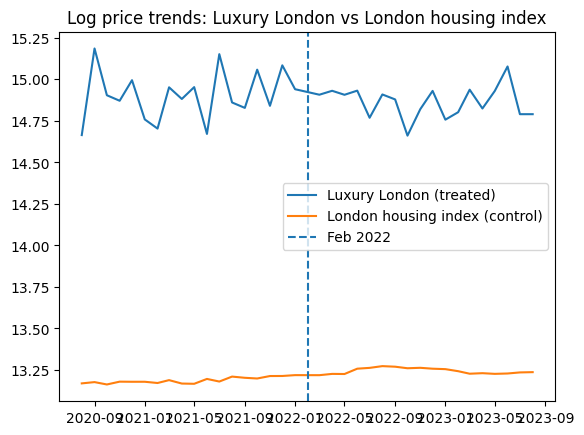

In [14]:
#import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf

# this regression uses the London house price index as the control series
# and the average luxury transaction price as the treated series

#importing data
lux = pd.read_csv("price_paid_monthly.csv")
hpi = pd.read_csv("cleaned_uk_houseprice_sheet2.csv")

#cleaning luxury real estate market data
lux["month"] = pd.to_datetime(lux["month"], errors="coerce")
lux["total_value"] = pd.to_numeric(lux["total_value"], errors="coerce")
lux["property_count"] = pd.to_numeric(lux["property_count"], errors="coerce")

lux["avg_price"] = lux["total_value"] / lux["property_count"]  # creates average transaction price
lux = lux.replace([np.inf, -np.inf], np.nan).dropna(subset=["month", "avg_price"])
lux = lux[lux["avg_price"] > 0].copy()

# convert to monthly period so matching is done by month, not exact day
lux["month"] = lux["month"].dt.to_period("M")

df_lux = lux[["month", "avg_price"]].copy()
df_lux["treated"] = 1  # luxury prices as treated series

#house price index by date
hpi["Date"] = pd.to_datetime(hpi["Date"], errors="coerce")
hpi = hpi.dropna(subset=["Date"])

CONTROL_COL = "London"  # can be switched to "London" or "United Kingdom"
hpi[CONTROL_COL] = pd.to_numeric(hpi[CONTROL_COL], errors="coerce")
hpi = hpi.dropna(subset=[CONTROL_COL])
hpi = hpi[hpi[CONTROL_COL] > 0].copy()

# convert to monthly period so matching is done by month, not exact day
hpi["month"] = hpi["Date"].dt.to_period("M")

df_ctrl = hpi[["month", CONTROL_COL]].rename(columns={CONTROL_COL: "avg_price"}).copy()
df_ctrl["treated"] = 0  # control series

df = pd.concat([df_lux, df_ctrl], ignore_index=True)

common_months = sorted(set(df_lux["month"]).intersection(set(df_ctrl["month"])))  #align time
df = df[df["month"].isin(common_months)].copy()
df = df.sort_values(["month", "treated"]).reset_index(drop=True)

df["avg_price"] = pd.to_numeric(df["avg_price"], errors="coerce")
df = df.replace([np.inf, -np.inf], np.nan).dropna(subset=["avg_price"])
df = df[df["avg_price"] > 0].copy()

df["log_price"] = np.log(df["avg_price"].astype(float))  #transform to logs, interpretation in % change

# 18 months pre vs 18 months post invasion time
invasion = pd.Period("2022-02", freq="M")

pre_start  = invasion - 18
pre_end    = invasion - 1

post_start = invasion + 1
post_end   = invasion + 18

#keeping only the window
df_window = df[
    ((df["month"] >= pre_start) & (df["month"] <= pre_end)) |
    ((df["month"] >= post_start) & (df["month"] <= post_end))
].copy()

df_window["post"] = (df_window["month"] >= post_start).astype(int)  # post-invasion period indicator
df_window["treated"] = df_window["treated"].astype(int)
df_window["treated_post"] = (df_window["treated"] * df_window["post"]).astype(int)

# create month fixed effect key
df_window["month_cat"] = df_window["month"].astype("object")

# DiD regression in logs
model = smf.ols("log_price ~ treated + treated_post + C(month_cat)",data=df_window).fit(cov_type="HC1")

did = model.params["treated_post"]

print("Pre window:", pre_start, "to", pre_end)
print("Post window:", post_start, "to", post_end)
print(model.summary())
print("DiD (log points):    ", float(did))
print("Approx % effect:     ", float(did * 100))

#plotting
plot_df = df_window.groupby(["month", "treated"])["log_price"].mean().reset_index()
plot_df["month_ts"] = plot_df["month"].dt.to_timestamp()

plt.figure()
plt.plot(plot_df[plot_df["treated"] == 1]["month_ts"],plot_df[plot_df["treated"] == 1]["log_price"],label="Luxury London (treated)")
plt.plot(plot_df[plot_df["treated"] == 0]["month_ts"],plot_df[plot_df["treated"] == 0]["log_price"],label="London housing index (control)")
plt.axvline(invasion.to_timestamp(), linestyle="--", label="Feb 2022")
plt.title("Log price trends: Luxury London vs London housing index")
plt.legend()
plt.show()

In [15]:
#did where ftse 350 is the control variable and luxury real estate market as treated

#load data
ftse = pd.read_csv("ftse_350_monthly.csv")

#reformat from date to month data
ftse["month"] = pd.to_datetime(ftse["Date"], errors="coerce")
ftse["Price"] = pd.to_numeric(ftse["Price"], errors="coerce")
ftse = ftse.dropna(subset=["month", "Price"])
ftse = ftse[ftse["Price"] > 0].copy()
ftse["month"] = ftse["month"].dt.to_period("M")

df_ftse = ftse[["month", "Price"]].rename(columns={"Price": "avg_price"}).copy()
df_ftse["treated"] = 0  # FTSE as control

# luxury prices as treated
df_lux_ftse = df_lux.copy()

# combine datasets
df_ftse_combined = pd.concat([df_lux_ftse, df_ftse], ignore_index=True)

# aligning time
common_months = sorted(set(df_lux_ftse["month"]).intersection(set(df_ftse["month"])))
df_ftse_combined = df_ftse_combined[df_ftse_combined["month"].isin(common_months)].copy()

df_ftse_combined = df_ftse_combined.sort_values(["month", "treated"]).reset_index(drop=True)

# log transformation
df_ftse_combined = df_ftse_combined[df_ftse_combined["avg_price"] > 0].copy()
df_ftse_combined["log_price"] = np.log(df_ftse_combined["avg_price"])

# applying the same window of interest
df_ftse_window = df_ftse_combined[
    ((df_ftse_combined["month"] >= pre_start) & (df_ftse_combined["month"] <= pre_end)) |
    ((df_ftse_combined["month"] >= post_start) & (df_ftse_combined["month"] <= post_end))
].copy()

df_ftse_window["post"] = (df_ftse_window["month"] >= post_start).astype(int)
df_ftse_window["treated"] = df_ftse_window["treated"].astype(int)
df_ftse_window["treated_post"] = df_ftse_window["treated"] * df_ftse_window["post"]

# month fixed effects
df_ftse_window["month_cat"] = df_ftse_window["month"].astype(object)

# did regression
model_ftse = smf.ols("log_price ~ treated + treated_post + C(month_cat)",data=df_ftse_window).fit(cov_type="HC1")

print(model_ftse.summary())

did_ftse = model_ftse.params["treated_post"]

print("DiD (log points):", float(did_ftse))
print("Approx % effect:", float(did_ftse * 100))

                            OLS Regression Results                            
Dep. Variable:              log_price   R-squared:                       1.000
Model:                            OLS   Adj. R-squared:                  0.999
Method:                 Least Squares   F-statistic:                     3223.
Date:                Wed, 11 Mar 2026   Prob (F-statistic):           1.76e-51
Time:                        14:35:36   Log-Likelihood:                 93.501
No. Observations:                  72   AIC:                            -111.0
Df Residuals:                      34   BIC:                            -24.49
Df Model:                          37                                         
Covariance Type:                  HC1                                         
                                             coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------------

Sanctions intensity effect (HC1 robust):
coef: 0.00010112094794157996
se:   inf
pval: 1.0
95% CI: (-inf, inf)
Approx % per +1 sanctioned person: 0.010112094794157997


/Users/petrahalaszova/miniconda3/lib/python3.12/site-packages/statsmodels/regression/linear_model.py:1992: RuntimeWarning: divide by zero encountered in scalar divide
  self.het_scale = self.nobs/(self.df_resid)*(self.wresid**2)


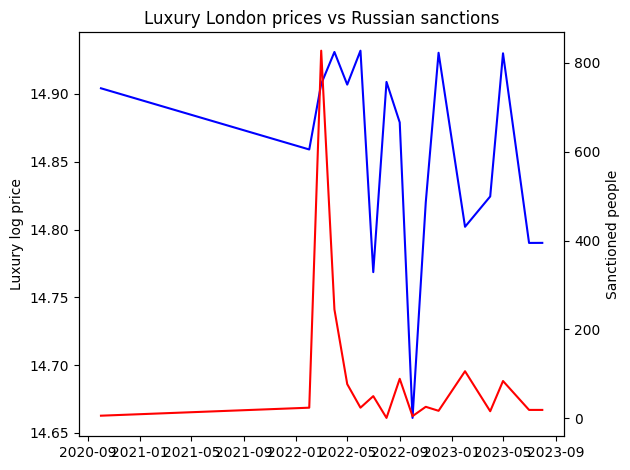

In [16]:
# sanctions intensity regression

# load sanctions data
sanction = pd.read_csv("sanctioned_monthly.csv")

#cleaning sanctions data
sanction["month"] = pd.to_datetime(sanction["month"], errors="coerce")
sanction["unique_sanctioned_people"] = pd.to_numeric(sanction["unique_sanctioned_people"], errors="coerce")
sanction = sanction.dropna(subset=["month", "unique_sanctioned_people"]).copy()
sanction["month"] = sanction["month"].dt.to_period("M")

# building luxury monthly series for sanctions regression
df_san = df_lux.copy()

# merging the sanctions onto luxury data
df_san = df_san.merge(san[["month", "unique_sanctioned_people"]], on="month", how="inner")

# keeping the same window
df_san = df_san[
    ((df_san["month"] >= pre_start) & (df_san["month"] <= post_end))
].copy()

# log of luxury prices
df_san = df_san[df_san["avg_price"] > 0].copy()
df_san["log_price"] = np.log(df_san["avg_price"])

# monthly fixed effects
df_san["month_cat"] = df_san["month"].astype(object)

#fitting model (robust)
model_sanctions = smf.ols("log_price ~ unique_sanctioned_people + C(month_cat)",data=df_san).fit(cov_type="HC1")

# printing only the key coefficient (robust inference)
coef = model_sanctions.params["unique_sanctioned_people"]
se   = model_sanctions.bse["unique_sanctioned_people"]
pval = model_sanctions.pvalues["unique_sanctioned_people"]
ci_l, ci_u = model_sanctions.conf_int().loc["unique_sanctioned_people"].tolist()

print("Sanctions intensity effect (HC1 robust):")
print("coef:", float(coef))
print("se:  ", float(se))
print("pval:", float(pval))
print("95% CI:", (float(ci_l), float(ci_u)))
print("Approx % per +1 sanctioned person:", float(coef * 100))

#plot
plot_san = df_san.copy()
plot_san["month_ts"] = plot_san["month"].dt.to_timestamp()

fig, ax1 = plt.subplots()

ax1.plot(plot_san["month_ts"], plot_san["log_price"], label="Luxury prices (log)", color="blue")
ax1.set_ylabel("Luxury log price")

ax2 = ax1.twinx()
ax2.plot(plot_san["month_ts"], plot_san["unique_sanctioned_people"], color="red", label="Sanctioned individuals")
ax2.set_ylabel("Sanctioned people")

plt.title("Luxury London prices vs Russian sanctions")
fig.tight_layout()
plt.show()